# Apply Neural Networks for Classification

We apply a simple neural network to Bank Customer Churn Prediction binary classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('../dataset/Bank Customer Churn Prediction.csv')
#df.dtypes
one_hot_country = pd.get_dummies(df.country, prefix='country')
one_hot_gender = pd.get_dummies(df.gender, prefix='gender')
df = df.drop(["country","gender"],axis=1)
df = pd.concat([df, one_hot_country, one_hot_gender], axis=1)

df = df.drop(['customer_id'], axis='columns')
X = df.drop(['churn'], axis='columns')
y = df['churn']

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,True,False,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,True,False,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,True,False,False,True,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,False,True,False,False,True


In [2]:
X_train.shape

(8000, 13)

## Network 1
The network outputs a single activation node (it is a binary classification) with sigmoid activation.
It means the network outputs a (0,1) value. The is the probability of the class being class = 1

![](figures/neural1.png)

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Input


model = Sequential([
Input(shape=(X_train.shape[1],)),
Dense(100, activation="relu"),
Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501 (5.86 KB)

 Trainable params: 1,501 (5.86 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#model.compile(loss='binary_crossentropy', optimizer='adam')

# I want to compute the accuracy while training

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7802 - loss: 0.4997 - val_accuracy: 0.7956 - val_loss: 0.4692
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8056 - loss: 0.4496 - val_accuracy: 0.8062 - val_loss: 0.4508
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8080 - loss: 0.4369 - val_accuracy: 0.8156 - val_loss: 0.4386
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8164 - loss: 0.4244 - val_accuracy: 0.8194 - val_loss: 0.4289
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8213 - loss: 0.4154 - val_accuracy: 0.8175 - val_loss: 0.4191
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8242 - loss: 0.4037 - val_accuracy: 0.8288 - val_loss: 0.4103
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8309 - loss: 0.3929 - val_accuracy: 0.8294 - val_loss: 0.4004
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8369 - loss: 0.3824 - val_accu

In [5]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.780156,0.499718,0.795625,0.469233
1,0.805625,0.449567,0.806250,0.450759
2,0.807969,0.436940,0.815625,0.438610
3,0.816406,0.424427,0.819375,0.428941
4,0.821250,0.415406,0.817500,0.419097
...,...,...,...,...
95,0.875156,0.309987,0.846250,0.360874
96,0.873281,0.309313,0.849375,0.359897
97,0.876250,0.307998,0.850000,0.362182
98,0.876250,0.308268,0.842500,0.360799


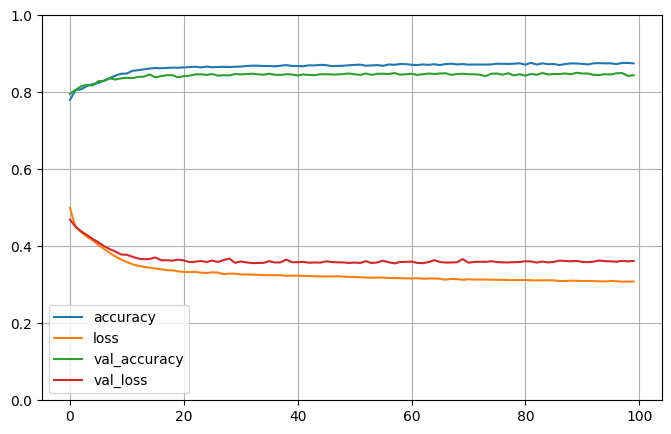

In [6]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [7]:
y_pred = model.predict(X_test)
y_pred.shape

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


(2000, 1)

In [8]:
y_pred[0]

array([0.2837189], dtype=float32)

In [9]:
y_pred = model.predict(X_test)
y_pred01 = y_pred.copy()
y_pred01[y_pred >= 0.5] = 1
y_pred01[y_pred < 0.5] = 0
print(confusion_matrix(y_test, y_pred01))
print(classification_report(y_test, y_pred01))
print(accuracy_score(y_test, y_pred01)) 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step
[[1499   79]
 [ 238  184]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1578
           1       0.70      0.44      0.54       422

    accuracy                           0.84      2000
   macro avg       0.78      0.69      0.72      2000
weighted avg       0.83      0.84      0.83      2000

0.8415


In [12]:
y_pred[0]

array([0.16806939], dtype=float32)

## Network 2

The network outputs 2 activation nodes (it is a binary classification) with softmax activation.

![](figures/neural2.png)

In [10]:
model = Sequential([
Input(shape=(X_train.shape[1],)),
Dense(100, activation="relu"),
Dense(2, activation="softmax")
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602 (6.26 KB)

 Trainable params: 1,602 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4801 - val_loss: 0.4653
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4443 - val_loss: 0.4440
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4284 - val_loss: 0.4363
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4179 - val_loss: 0.4223
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4092 - val_loss: 0.4139
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3987 - val_loss: 0.4051
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3884 - val_loss: 0.3975
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3784 - val_loss: 0.3863
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3669 - val_loss: 0.3788
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3594 - val_loss: 0.3764
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3542 - val_loss: 0.3711
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

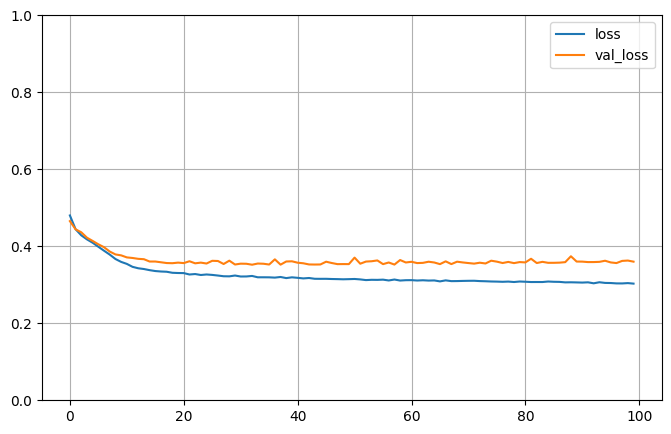

In [12]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [14]:
y_pred = model.predict(X_test)
print(y_pred.shape)
y_pred[0]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
(2000, 2)


array([0.8432017 , 0.15679835], dtype=float32)

In [15]:
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1518   60]
 [ 265  157]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1578
           1       0.72      0.37      0.49       422

    accuracy                           0.84      2000
   macro avg       0.79      0.67      0.70      2000
weighted avg       0.82      0.84      0.82      2000



In [33]:
y_pred = model.predict(X_test)
y_pred[0]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([0.64175683, 0.35824308], dtype=float32)

## Network 3

In this network we explore the case where y-values are one-hot encoded


In [17]:
y = pd.get_dummies(df['churn'], prefix='churn')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y

,churn_0,churn_1
0,False,True
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
9995,True,False
9996,True,False
9997,False,True
9998,False,True


In [35]:
y_train

,churn_0,churn_1
532,True,False
8773,True,False
9868,True,False
9728,False,True
3449,True,False
...,...,...
3260,False,True
3187,True,False
8253,False,True
8232,True,False


In [18]:
from keras.models import Sequential
from keras.layers import Dense, Input


model = Sequential([
Input(shape=(X_train.shape[1],)),
Dense(100, activation="relu"),
Dense(2, activation="softmax")
])
model.compile(loss='categorical_crossentropy', optimizer='adam') # <----
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4819 - val_loss: 0.4820
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4400 - val_loss: 0.4656
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4250 - val_loss: 0.4639
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4121 - val_loss: 0.4457
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4002 - val_loss: 0.4339
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3892 - val_loss: 0.4190
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3802 - val_loss: 0.4101
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3705 - val_loss: 0.4028
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3639 - val_loss: 0.4034
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3580 - val_loss: 0.3872
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3522 - val_loss: 0.3891
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

In [29]:
(X_train.shape[0] * 0.8)/32

200.0

In [31]:
X_train.shape[0]

8000

In [38]:
y_pred = model.predict(X_test)
y_pred.shape

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


(2000, 2)

In [37]:
y_pred = model.predict(X_test)
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test['churn_1'], y_pred))
print(classification_report(y_test['churn_1'], y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[1472  102]
 [ 200  226]]
              precision    recall  f1-score   support

       False       0.88      0.94      0.91      1574
        True       0.69      0.53      0.60       426

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.84      0.85      0.84      2000



## Network 4

In this network we add some balancing among training examples, and a call back to stop training is the model does not improve.
We also add a layer to the network

In [20]:
X = df.drop(['churn'], axis='columns')
y = df['churn']
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [21]:
num_classes = 2
input_shape = (X_train.shape[1],)
model = Sequential([
Input(shape=input_shape),
Dense(100, activation="relu"),
Dense(100, activation="relu"),
Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,702 (45.71 KB)

 Trainable params: 11,702 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
class_weights = {0:0.1, 1:5}
class_weights


{0: 0.1, 1: 5}

In [30]:
import keras

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20),
]


model.compile(loss='categorical_crossentropy', optimizer='adam')
history = model.fit(X_train, pd.get_dummies(y_train), epochs=100, validation_split=0.2, class_weight=class_weights, callbacks=callbacks)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1382 - val_loss: 1.2410
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1343 - val_loss: 1.0408
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1334 - val_loss: 0.8270
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1357 - val_loss: 1.1206
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1331 - val_loss: 1.2264
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1330 - val_loss: 1.3067
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1349 - val_loss: 1.1370
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1296 - val_loss: 1.1297
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1283 - val_loss: 1.0852
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1262 - val_loss: 1.2835
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1293 - val_loss: 1.2203
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

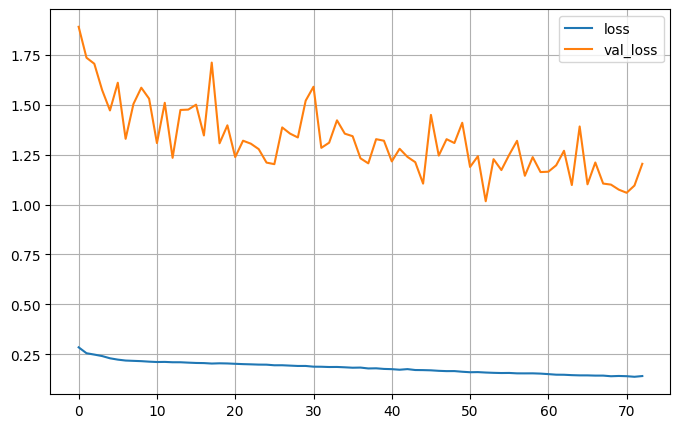

In [26]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [27]:
y_pred = model.predict(X_test)
#y_pred[y_pred >= 0.5] = 1
#y_pred[y_pred < 0.5] = 0
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[750 861]
 [ 39 350]]
              precision    recall  f1-score   support

           0       0.95      0.47      0.62      1611
           1       0.29      0.90      0.44       389

    accuracy                           0.55      2000
   macro avg       0.62      0.68      0.53      2000
weighted avg       0.82      0.55      0.59      2000

